## Implementación de Regresión Logística-PyTorch

### Descarga del conjunto de datos y Análisis de características

---
Primeramente se realizará la carga de los datos en un dataframe, para posteriormente poder realizar un análisis exploratorio de los datos.


---

In [479]:
import pandas as pd

df = pd.read_csv('winequality-red.csv')
# Display de los primeros 5 registros del DataFrame 
print(df.head())

# Imprimir el total de datos que contiene el DataFrame 

print(f"Total de datos en el DataFrame: {len(df)}")



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

---
Una vez teniendo cargado el dataset en el dataframe df podemos empezar con el análisis. De modo que primeramente podemos plotear algunos diagramas importantes para ver la relación que puedan tener estos features con el target, que en este caso es quality. Podemos hacer uso de los siguientes gráficos: 
- Dispersion
- De Cajas
- Histograma
- Matriz de Correlacion


Sin embargo primeramente vamos a explorar si hay filas repetidas en el dataset las cuales nos aportan la misma información o también filas en las que falte información en algunas de las casillas.

---

In [480]:
#Explorar filas duplicadas 

df_duplicates = df[df.duplicated()]
print(f"Numero de filas duplicadas: {len(df_duplicates)}")

Numero de filas duplicadas: 240


In [481]:
#Explorar valores nulos o faltantes

df_missing = df.isnull().sum()
print("Valores faltantes por columna:")
print(df_missing)

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


---

Por lo tanto se podrian eliminar 240 filas del dataset debido a los datos duplicados que no nos aportan informacion nueva y con respecto a los datos faltantes no seria necesario aplicar ninguna tecnica de feature engineering debido a que no hay missing values. 

---

In [482]:
#Eliminar filas duplicadas 

df = df.drop_duplicates()
print(f"Total de datos despues de eliminar duplicados: {len(df)}")


Total de datos despues de eliminar duplicados: 1359


---

Luego de haber eliminado filas con datos duplicados y comprobar si existian missing values se puede continuar con los gráficos que nos ayudarán mejor a comprender el comportamiento de los features con respecto a la variable objetivo

#### Histogramas
Estos nos ayudaran a entender y visualizar mejor la distribucion de los datos y ademas tambien conocer el rango de valores dentro del cual los features se encuentran, ya que estos pueden diferir, por lo cual luego se deberan aplicar tecnicas de normalizacion.

---

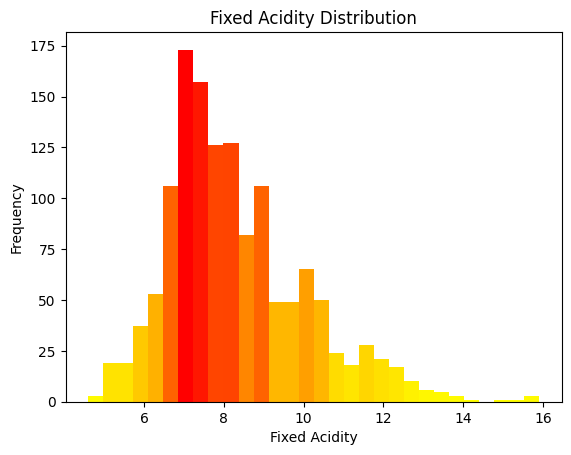

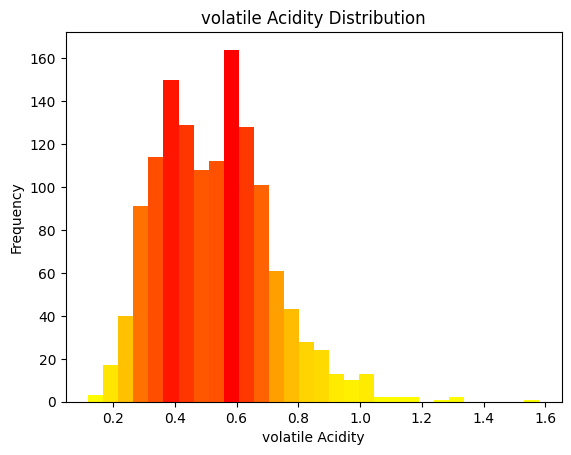

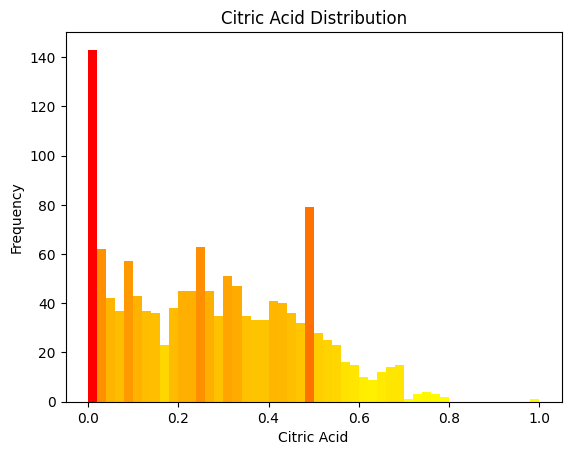

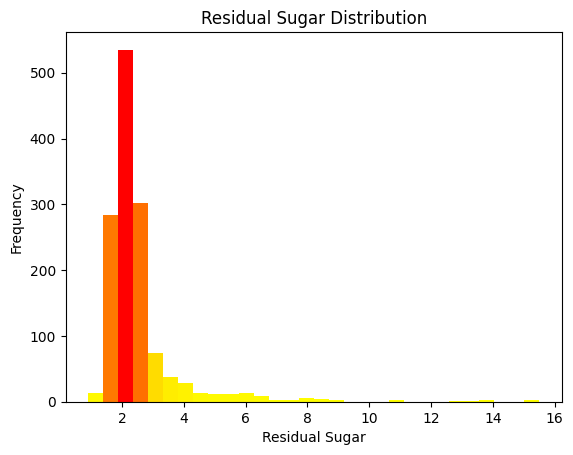

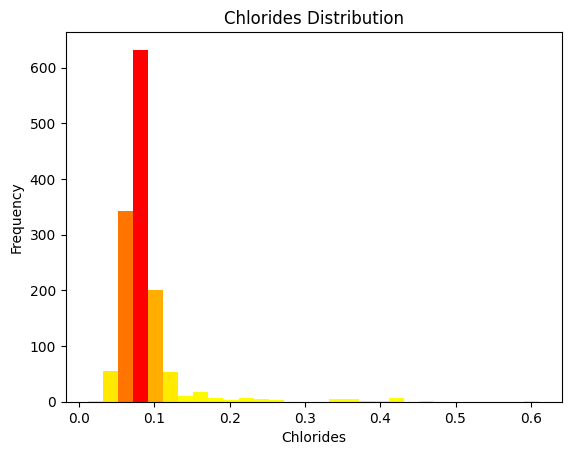

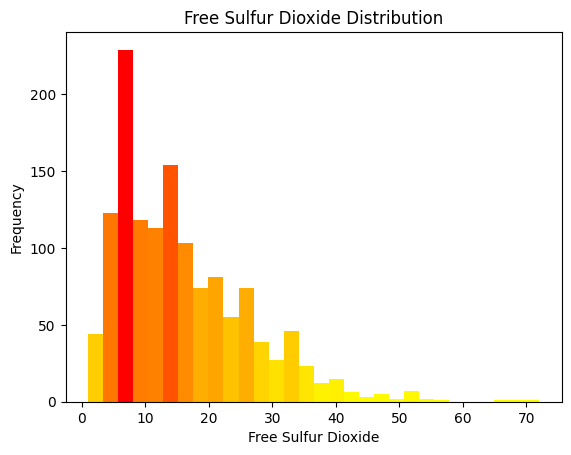

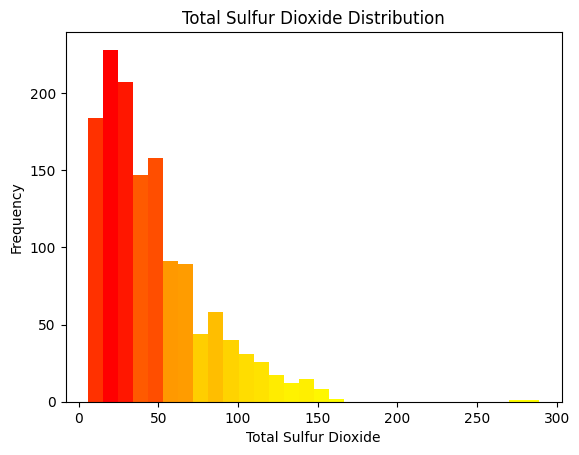

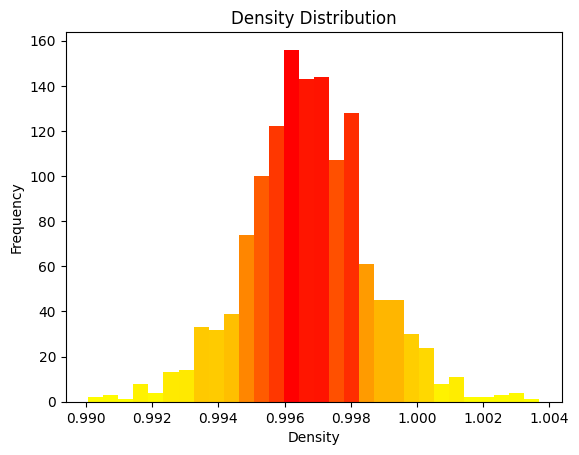

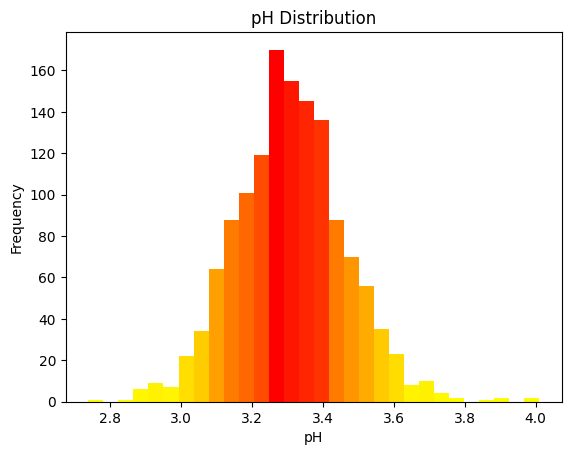

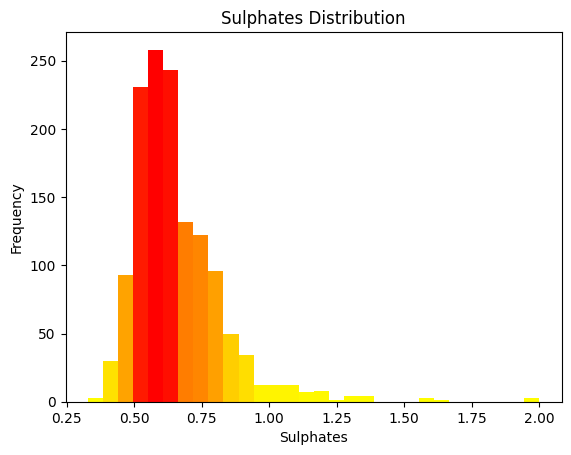

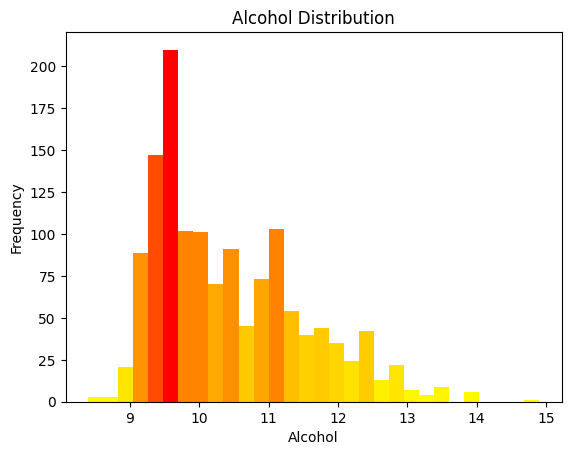

In [483]:
import matplotlib.pyplot as plt
import numpy as np
features = df[["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]]

#Crear histogramas para cada feature 
#histograma de fixed acidity
N, bins, patches = plt.hist(features["fixed acidity"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Fixed Acidity Distribution")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")
plt.show()

#histograma de volatile acidity
N, bins, patches = plt.hist(features["volatile acidity"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("volatile Acidity Distribution")
plt.xlabel("volatile Acidity")
plt.ylabel("Frequency")
plt.show()

#histograma de citric acid
N, bins, patches = plt.hist(features["citric acid"], bins=50)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Citric Acid Distribution")
plt.xlabel("Citric Acid")
plt.ylabel("Frequency")
plt.show()

#histograma de residual sugar
N, bins, patches = plt.hist(features["residual sugar"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Residual Sugar Distribution")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

#histograma de chlorides
N, bins, patches = plt.hist(features["chlorides"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Chlorides Distribution")
plt.xlabel("Chlorides")
plt.ylabel("Frequency")
plt.show()

#histograma de free sulfur dioxide
N, bins, patches = plt.hist(features["free sulfur dioxide"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Free Sulfur Dioxide Distribution")
plt.xlabel("Free Sulfur Dioxide")
plt.ylabel("Frequency")
plt.show()

#histograma de total sulfur dioxide
N, bins, patches = plt.hist(features["total sulfur dioxide"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Total Sulfur Dioxide Distribution")
plt.xlabel("Total Sulfur Dioxide")
plt.ylabel("Frequency")
plt.show()

#histograma de density
N, bins, patches = plt.hist(features["density"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

#histograma de pH
N, bins, patches = plt.hist(features["pH"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()
#histograma de sulphates
N, bins, patches = plt.hist(features["sulphates"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Sulphates Distribution")
plt.xlabel("Sulphates")
plt.ylabel("Frequency")
plt.show()
#histograma de alcohol
N, bins, patches = plt.hist(features["alcohol"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()




---

- Como podemos observar en PH distribution, Fixed Acidity distribution y en Density distribution hay una tendencia hacia la normalidad, en volatile acidity hay una tendencia o sesgo bimodal, en los demas hay una distribucion sesgada a la derecha y en otros se podria decir que es una tendencia normal, con valores de frecuencia muy altos y otros muy bajos, haciendo gran contraste. 
- Tambien se puede observar las distintas escalas en las que estan los features ya que en algunos los valores pueden ir de 10 en 10 hasta 300, y otros en intervalos de 0,001 desde 0 a 1. 

### Datos outliers

Como se puede observar en algunos de los histogramas existen barras correspondientes a cierta cantidad de frecuencia de datos dentro del feature, sin embargo hay barras que se dispersan un poco más de las frecuencias más altas y centrales, de manera que podríamos realizar un análisis de datos que estén fuera de cierto rango óptimo para ser considerado un dato óptimo dentro de cierta clase o ser considerado un outlier. 
Primeramente se desplegarán los siguientes datos: 
- Moda
- Mediana
- Desviación estandar
- Cuartiles
- Máximos
- Mínimos

In [484]:
# Estadísticas descriptivas 
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


---

En el caso de citric acid vemos que el valor minimo marcó cero en alguna de todas las muestras tomadas, esto podría ser o no ser un error en la medición.

---

Podemos observar como para el caso de "free sulfur dioxide" y "total sulfur dioxide" los datos se dispersan bastante de la media, por lo cual la desviación estandar es bastante grande, además podemos observar que en algunos de los casos el rango intercuartilico al aplicar la formula para el cuartil 1 y el cuartil 3 estos podrían no contener algunos de los valores maximos y minimos por lo cual esto es un indicio de outliers en algunos de los features. Q1-1.5 * IQR y Q3+1.5 * IQR

### Diagramas de cajas

---

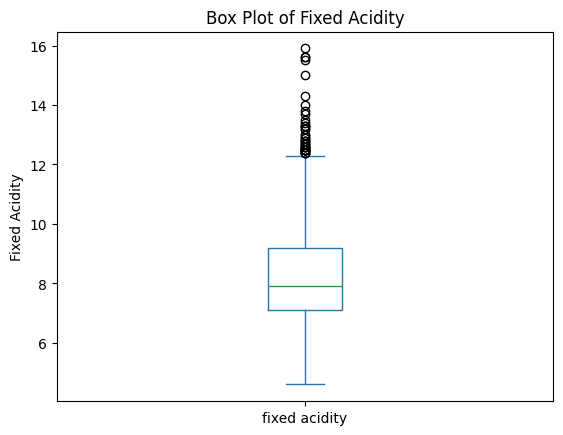

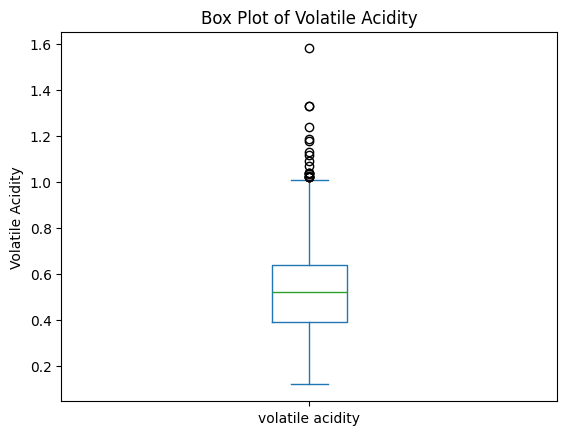

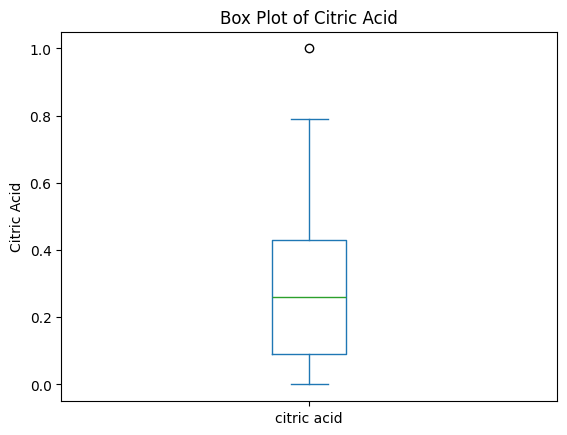

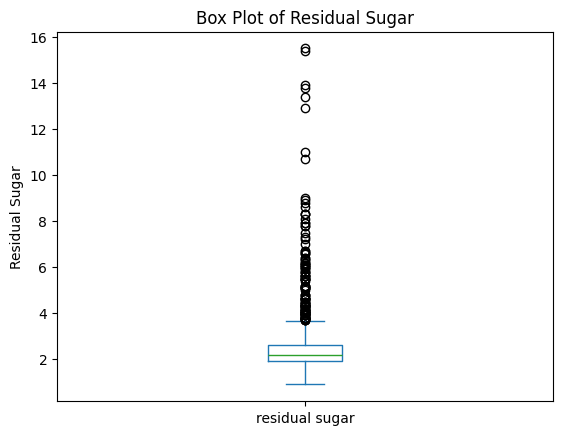

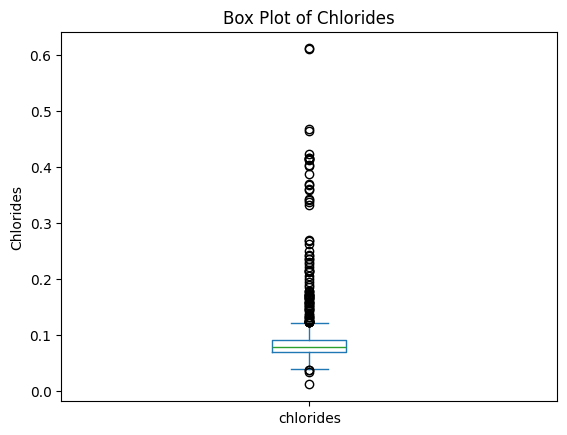

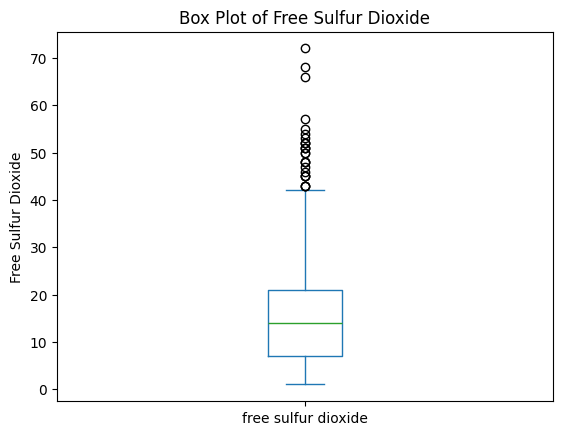

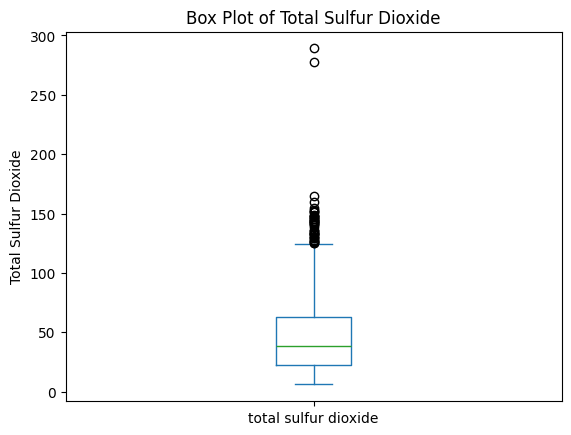

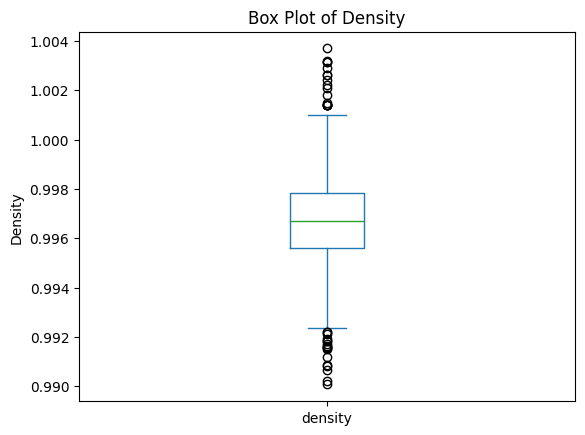

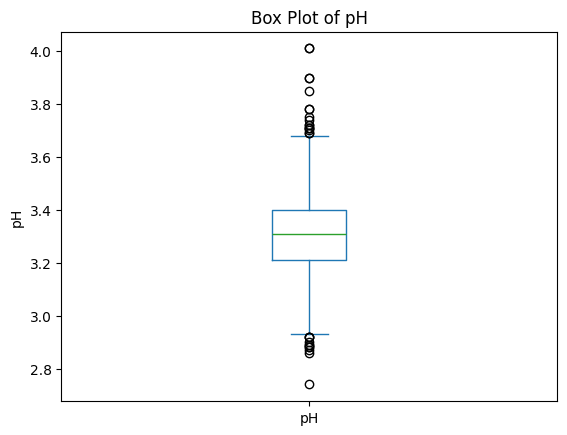

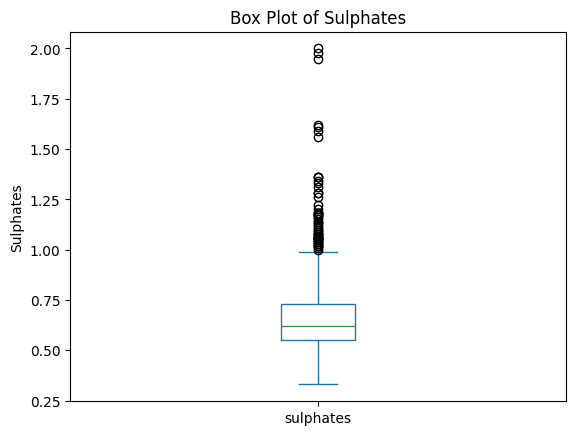

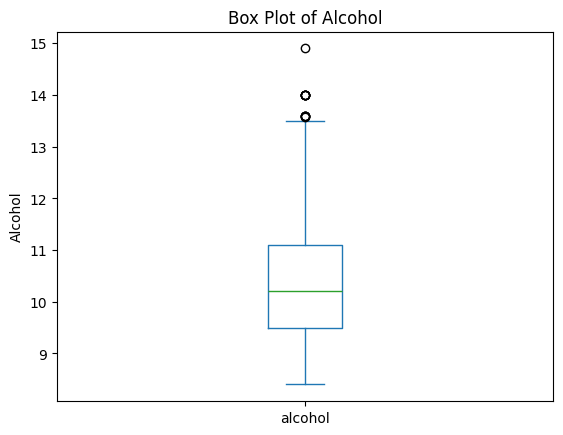

In [485]:
#diagrama de cajas para fixed acidity
features["fixed acidity"].plot.box()
plt.title("Box Plot of Fixed Acidity")
plt.ylabel("Fixed Acidity")
plt.show()
#diagrama de cajas para volatile acidity
features["volatile acidity"].plot.box()
plt.title("Box Plot of Volatile Acidity")
plt.ylabel("Volatile Acidity")
plt.show()
#diagrama de cajas para citric acid
features["citric acid"].plot.box()
plt.title("Box Plot of Citric Acid")
plt.ylabel("Citric Acid")
plt.show()
#diagrama de cajas para residual sugar
features["residual sugar"].plot.box()
plt.title("Box Plot of Residual Sugar")
plt.ylabel("Residual Sugar")
plt.show()
#diagrama de cajas para chlorides
features["chlorides"].plot.box()
plt.title("Box Plot of Chlorides")
plt.ylabel("Chlorides")
plt.show()
#diagrama de cajas para free sulfur dioxide
features["free sulfur dioxide"].plot.box()
plt.title("Box Plot of Free Sulfur Dioxide")
plt.ylabel("Free Sulfur Dioxide")
plt.show()
#diagrama de cajas para total sulfur dioxide
features["total sulfur dioxide"].plot.box()
plt.title("Box Plot of Total Sulfur Dioxide")
plt.ylabel("Total Sulfur Dioxide")
plt.show()
#diagrama de cajas para density
features["density"].plot.box()
plt.title("Box Plot of Density")
plt.ylabel("Density")
plt.show()
#diagrama de cajas para pH
features["pH"].plot.box()
plt.title("Box Plot of pH")
plt.ylabel("pH")
plt.show()
#diagrama de cajas para sulphates
features["sulphates"].plot.box()
plt.title("Box Plot of Sulphates")
plt.ylabel("Sulphates")
plt.show()
#diagrama de cajas para alcohol
features["alcohol"].plot.box()
plt.title("Box Plot of Alcohol")
plt.ylabel("Alcohol")
plt.show()



---

Tambien podemos identificar puntualmente la cantidad de outliers para cada uno de los features, esto nos podría decir cuales podrían ser los features más óptimos para trabajarlos y desarrollar la regresión logística con estos. 

---


In [486]:
#Cantidad de outliers por feature 
def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((serie < lower) | (serie > upper)).sum()

outlier_counts = features.apply(contar_outliers)
print("Cantidad de outliers por feature:")
print(outlier_counts)

Cantidad de outliers por feature:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
dtype: int64


---

Como se puede ver para cada feature existen outliers, los cuales debemos tratar con el fin de evitar que esto pueda sesgar el modelo de predicción final que vayamos a obtener, además estos outliers podrían estar alterando de cierta manera las características descriptivas que encontramos anteriormente. 
No podríamos tomar la decisión de eliminarlos inmediatamente ya que esto podría sesgar el modelo y además agregar alta varianza al disminuir el tamaño del dataset, por lo tanto se podrían aplicar la técnica de winsorización con el fin de no perder tanta información dentro del dataset. 

---

### Winsorizacion percentil
Lo siguiente a aplicar sería definir un percentil tanto para el valor superior como para el varior inferior, los cuales se van a tomar cómo límites y todos los valores que estén por encima o por abajo de estos valores se convertirán a los valores establecidos en los límites. Sin embargo para algunos de los casos no es ideal aplicar la winsorización ya que como vimos anteriormente en los histogramas la distribución en algunos casos está sesgada y no es simétrica esto puede introducir sesgos o hacer que se pierda información importante, por lo tanto solo se aplicará a los features que consideremos tengan una distribución simétrica y unimodal sin sesgos hacia la derecha o izquierda.

<i> **Por lo mencionado anteriormente los siguientes 7 features que se escogieron serán los que se tomen en cuenta para la winsorizacion, para la normalización y posteriormente para el gráfico de correlación, esto debido a que tienen una mejor distribución, lo cual disminuye el sesgo del modelo** </i>

---

In [487]:
import numpy as np
# Columnas con winsorización al 5%/95%
cols_5_95 = features

# Aplicar winsorización minima de 1.5 y 98.5 
for col in cols_5_95:
    p2 = np.percentile(df[col], 1.5)
    p98 = np.percentile(df[col], 98.5)
    df[col] = np.clip(df[col], p2, p98)

---

Ahora podemos ver los cambios luego de aplicar la winsorización a las características descriptivas de media y desviación estandar para los features dentro de cols_5_95 y para density que se le aplicó un percentil distinto. 

---

In [488]:
# Contar outliers después
def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((serie < lower) | (serie > upper)).sum()
# ver la cantidad de outliers después de winsorización
outlier_counts = df[["fixed acidity", "volatile acidity", "residual sugar", "chlorides", "density", "pH", "sulphates"]].apply(contar_outliers)
print("\nCantidad de outliers por feature después de winsorización:")
print(outlier_counts)


Cantidad de outliers por feature después de winsorización:
fixed acidity        41
volatile acidity      0
residual sugar      126
chlorides            83
density               0
pH                    0
sulphates            55
dtype: int64


Como se puede observar la cantidad de outliers disminuyó considerablemente al aplicar la técnica de winsorización a los features que seleccionamos, los cuales tenían una distribución unimodal y además con cierta simétría, sin utilizar features con sesgos fuertes a la derecha. Para los features residual sugar y chlorides se pueden eliminar las filas de los datos outliers, de modo que se mitigue el impacto de estos outliers en el modelo final. 

---

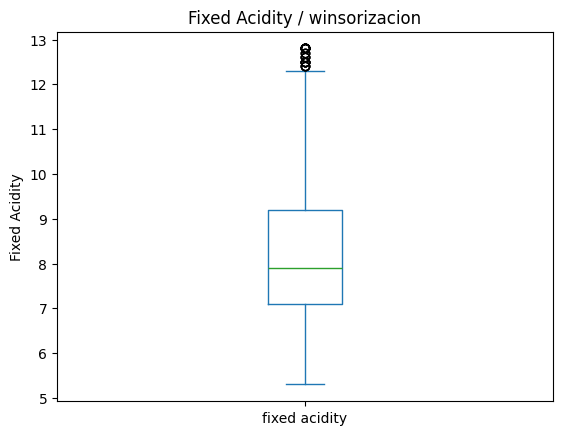

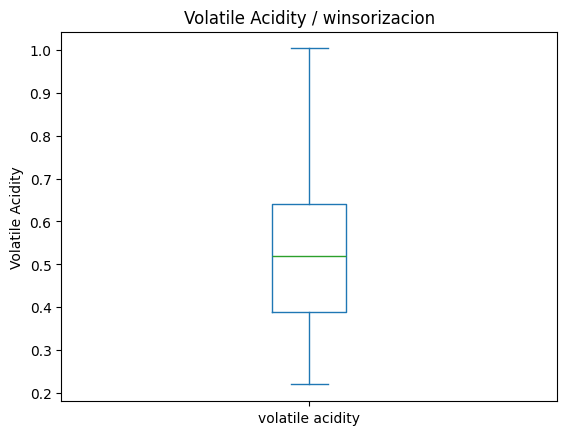

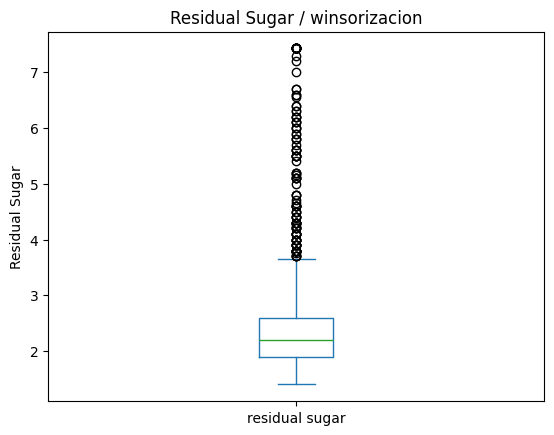

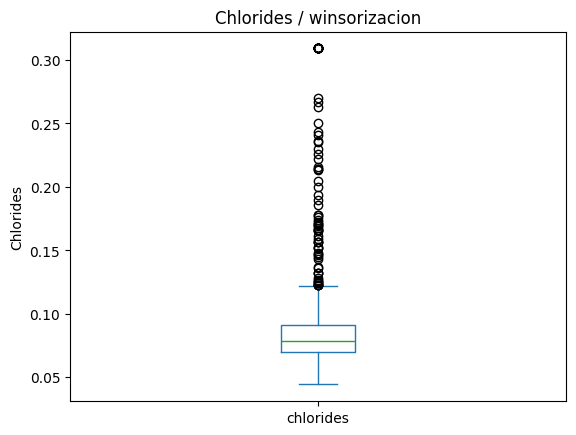

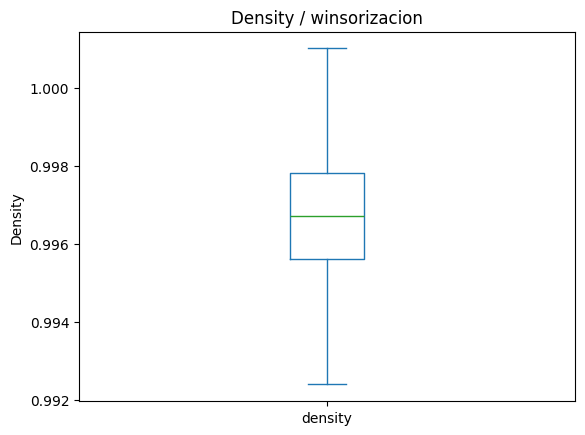

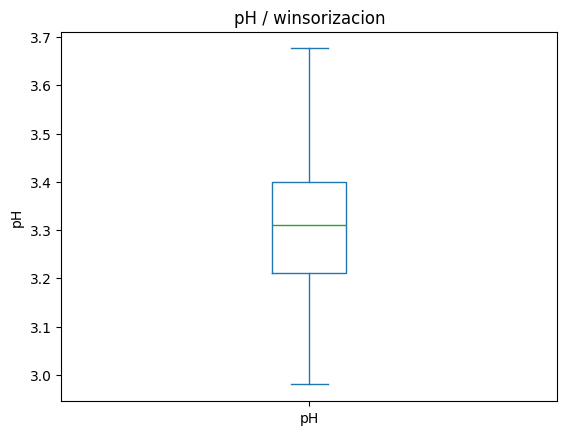

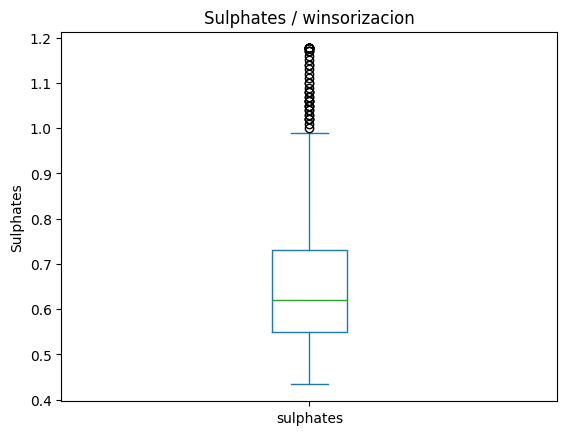

In [489]:
# Graficos de cajas para confirmar el cambio en los outliers

# grafico de cajas para fixed acidity
df["fixed acidity"].plot.box()
plt.title("Fixed Acidity / winsorizacion")
plt.ylabel("Fixed Acidity")
plt.show()

# grafico de cajas para volatile acidity
df["volatile acidity"].plot.box()
plt.title("Volatile Acidity / winsorizacion")
plt.ylabel("Volatile Acidity")
plt.show()

# grafico de cajas para residual sugar
df["residual sugar"].plot.box()
plt.title("Residual Sugar / winsorizacion")
plt.ylabel("Residual Sugar")
plt.show()

# grafico de cajas para chlorides
df["chlorides"].plot.box()
plt.title("Chlorides / winsorizacion")
plt.ylabel("Chlorides")
plt.show()

# grafico de cajas para density
df["density"].plot.box()
plt.title("Density / winsorizacion")
plt.ylabel("Density")
plt.show()

# grafico de cajas para pH
df["pH"].plot.box()
plt.title("pH / winsorizacion")
plt.ylabel("pH")
plt.show()

# grafico de cajas para sulphates
df["sulphates"].plot.box()
plt.title("Sulphates / winsorizacion")
plt.ylabel("Sulphates")
plt.show()


---

Como se puede observar en los diagramas de cajas anteriores, los outliers han disminuido debido a que se hicieron cambios con la técnica de winsorización, lo cual también representó cambios en la media y desviación estandar de cada uno de los features, ahora que ya no hay datos fuera de los rangos para los diagramas de cajas podemos seguir con la estandarización de los datos, ya que estos presentan escalas distintas, debido a que ya se eliminaron outliers el método z-score puede ser buena opción debido a que este es sensible a outliers, sin embargo estos ya se trataron.

Ahora una vez disminuidos los outliers vamos a eliminar los restantes en los features para evitar el sesgo y la alta varianza, además es necesario para que al estandarizar con el metodo z-score no se vea este afectado por el cambio de la media y la desviación provocado por los outliers.

In [490]:
#Eliminación de outliers restantes
# Selección de features
features = df[["fixed acidity", "volatile acidity", "residual sugar", "chlorides", "density", "pH", "sulphates"]]

# Función para eliminar outliers basados en IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Aplicar la función
df = remove_outliers_iqr(df, ["fixed acidity", "volatile acidity", "residual sugar", "chlorides", "density", "pH", "sulphates"])

# Ver tamaño antes y después
print("Antes:", df.shape)
print("Después:", df.shape)


Antes: (1094, 12)
Después: (1094, 12)


---

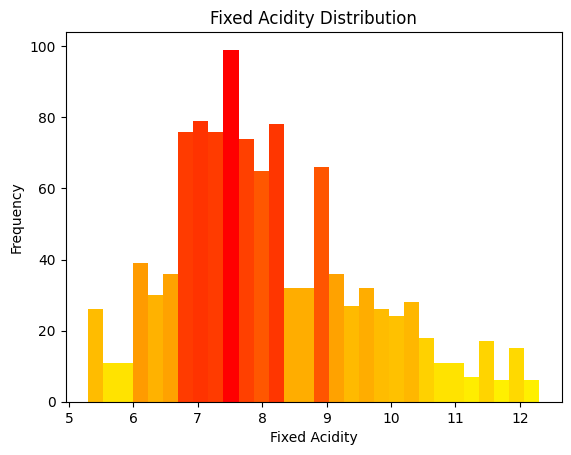

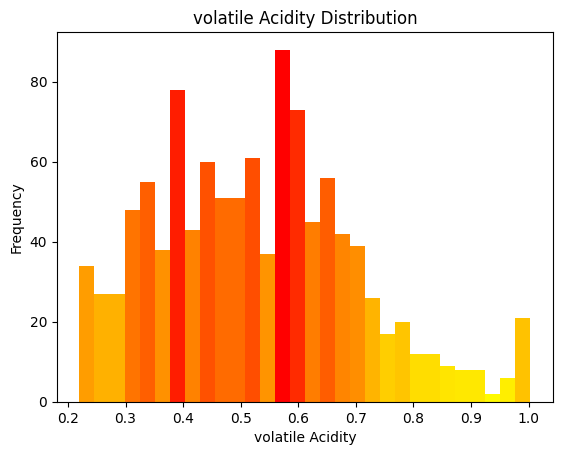

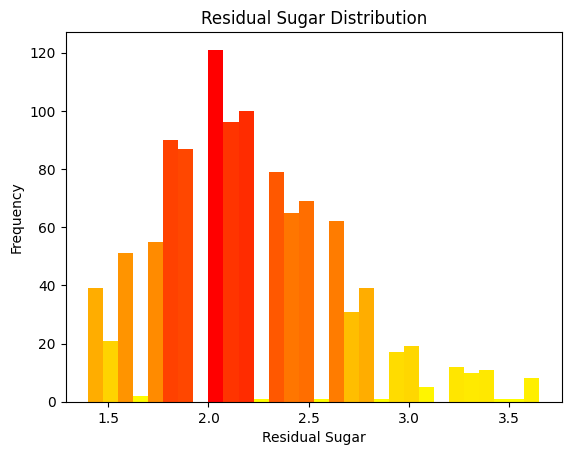

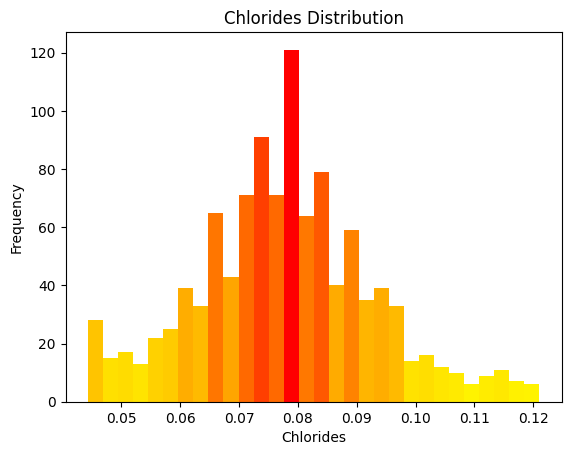

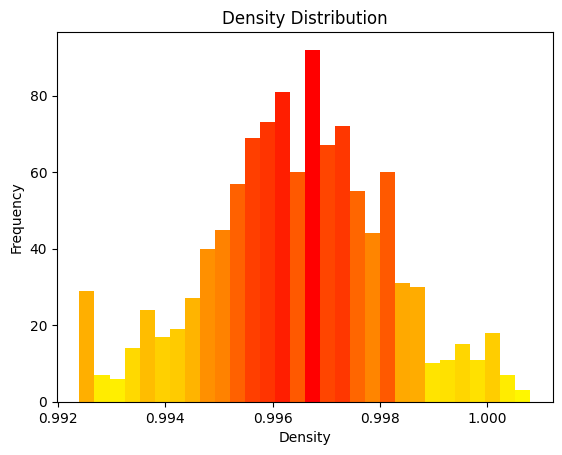

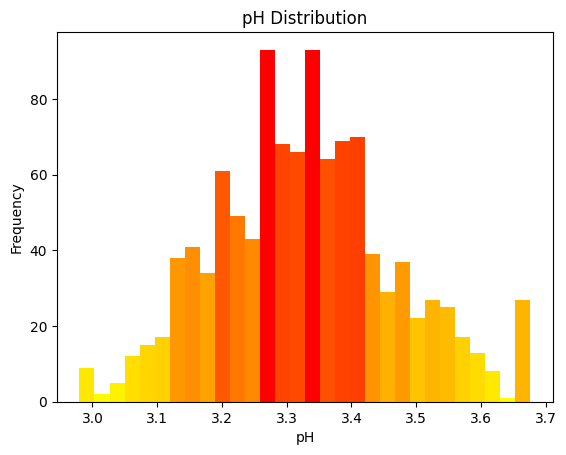

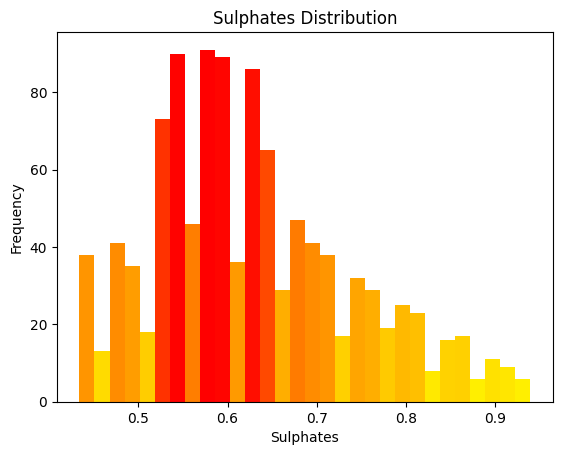

In [491]:
#histograma de fixed acidity
N, bins, patches = plt.hist(df["fixed acidity"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Fixed Acidity Distribution")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")
plt.show()

#histograma de volatile acidity
N, bins, patches = plt.hist(df["volatile acidity"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("volatile Acidity Distribution")
plt.xlabel("volatile Acidity")
plt.ylabel("Frequency")
plt.show()
#histograma de residual sugar
N, bins, patches = plt.hist(df["residual sugar"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Residual Sugar Distribution")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()
#histograma de chlorides
N, bins, patches = plt.hist(df["chlorides"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Chlorides Distribution")
plt.xlabel("Chlorides")
plt.ylabel("Frequency")
plt.show()
#histograma de density
N, bins, patches = plt.hist(df["density"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()
#histograma de pH
N, bins, patches = plt.hist(df["pH"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()
#histograma de sulphates
N, bins, patches = plt.hist(df["sulphates"], bins=30)
for count, patch in zip(N, patches):
    patch.set_facecolor(plt.cm.autumn_r(count / max(N)))  # más alto = color más intenso
plt.title("Sulphates Distribution")
plt.xlabel("Sulphates")
plt.ylabel("Frequency")
plt.show()

---

Como se puede observar la distribución cambió en los histogramas para los features seleccionados, además de esto se puede notar que en los extremos del histograma cambiaron y y ya no se ven datos descentralizados, la mayoría de las distribuciones tienen una forma equilibrada de modo que en ambos extremos la frecuencia es baja en la mayoria de los casos y en el centro para casi todas las distribuciones se ve una forma y en algunos casos una forma normal, como en density y en pH. 
Ahora podemos continuar con los gráficos que nos dictarán cual de los features tienen una relación más fuerte con nuestro target.
### Binarizar variable objetivo
Debido a que el objetivo es predecir si el vino va a ser bueno o no, podemos binarizar quality definiendo un umbral, por ejemplo para las calificaciones mayores o iguales  6 podemos decir que el vino es bueno ya que el máximo valor encontrado en el dataset para el target fue de 8 y el mínimo fue de 3, por lo tanto en una escala podemos definir que 3,4,5 y 6 son valores bajos, mientras que 7 y 8 son valores de una calificación para un buen vino.

In [492]:
df['target'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [493]:
df['target'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0) #Todos los datos de quality que sean menores a 6 se pondran como 0 y mayores a este se pondran como 1
df["target"].head()
df["target"].value_counts()


target
0    952
1    142
Name: count, dtype: int64

---

Como se puede observar los vinos considerados como buenos van a ser una minoria, esto podría tener implicaciones en el modelo de modo que este podría tener un sesgo hacia la parte de predicciones para vinos "no buenos".  Ahora podemos ver la correlación de los features tratados anteriormente (normalizados y aplicada la winsorización). 

---

### Mapa de calor
Este nos permitirá visualizar la relación de los features con el target, el cual se encuentra binarizado, esto con el objetivo de descartar un feature más, de modo que trabajemos solo con 6 features para la etapa de entrenamiento, validación y test.

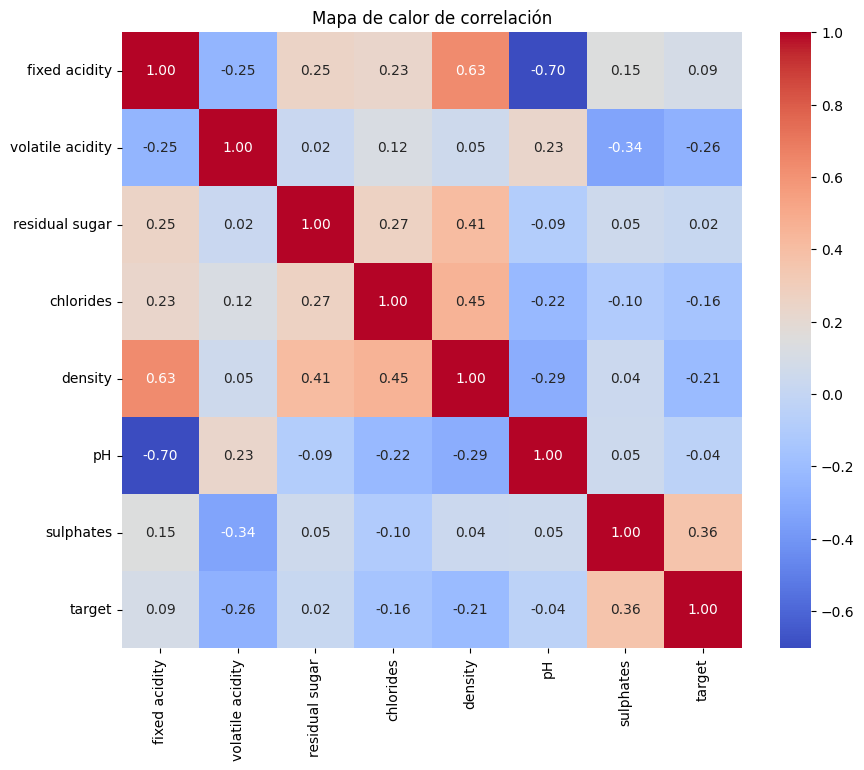

In [494]:
import seaborn as sns #Unicamente se utiliza para graficar 
import matplotlib.pyplot as plt

# Seleccionamos las columnas
features = df[["fixed acidity", "volatile acidity", "residual sugar", 
               "chlorides", "density", "pH", "sulphates", "target"]]

# Calculamos la matriz de correlación
corr_matrix = features.corr()

# Creamos el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") #se utiliza para graficar y darle cierto formato al mapa de calor 
plt.title("Mapa de calor de correlación")
plt.show()


---

Como se puede ver en el mapa de correlación el valor más grande de correlación directa con el target es de sulphates, mientras que volatile acidity es inversamente proporcinal para el valor de correlación con un -0.26, ahora bien debemos hacer una elección justificada de cual feature podríamos quitar para solo utilizar los 6 que sean más óptimos, ya teniendo el mapa de correlación podemos ver que fixed acidity está muy correlacionada con density y ademas con pH, de modo que aportan información similar, esto hace que exista multicolinealidad, por ende podríamos no utilizar fixed acidity para el entrenamiento y validar que tan óptimo resulta el modelo. 

**Ahora podemos hacer una división del dataset para el entrenamiento, debido a que hay un desbalance porque el target quedó con 184 muestras positivas para un buen vino y 1175 negativas, entonces utilizaremos división estratificada para mantener el sesgo.**

In [495]:
# Suponiendo que df es tu DataFrame con las columnas especificadas
features = ["volatile acidity", "residual sugar", "chlorides", "density", "pH", "sulphates", "target"] #quitamos el feature de fixed acidity de los features para el entrenamiento

#Separar features (X) y target (y)
X = df[features].drop(columns="target")
y = df["target"]
#Definir proporciones
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
#reproducibilidad
np.random.seed(42)


In [496]:
#Hacer la division y mezclar el dataframe para cada clase entrenamiento, validation y test
# Barajar y dividir estratificado
np.random.seed(42)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Dividir estratificado asegurando que 'target' se mantenga
train = df_shuffled.groupby("target").sample(frac=train_ratio, random_state=42)
temp = df_shuffled.drop(train.index)
val = temp.groupby("target").sample(frac=val_ratio/(val_ratio + test_ratio), random_state=42)
test = temp.drop(val.index)

# Separar X e y
X_train, y_train = train.drop(columns="target"), train["target"]
X_val, y_val = val.drop(columns="target"), val["target"]
X_test, y_test = test.drop(columns="target"), test["target"]

# Verificar tamaños y proporciones
print("Tamaño entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño validación:", X_val.shape, y_val.shape)
print("Tamaño prueba:", X_test.shape, y_test.shape)
print("\nProporción clases entrenamiento:\n", y_train.value_counts(normalize=True))
print("Proporción clases validación:\n", y_val.value_counts(normalize=True))
print("Proporción clases prueba:\n", y_test.value_counts(normalize=True))

Tamaño entrenamiento: (765, 12) (765,)
Tamaño validación: (165, 12) (165,)
Tamaño prueba: (164, 12) (164,)

Proporción clases entrenamiento:
 target
0    0.870588
1    0.129412
Name: proportion, dtype: float64
Proporción clases validación:
 target
0    0.866667
1    0.133333
Name: proportion, dtype: float64
Proporción clases prueba:
 target
0    0.871951
1    0.128049
Name: proportion, dtype: float64


---

Como se puede observar la proporción se mantiene equilibrada para cada set, en el primer caso en el de train con una proporcion de 0.87 aproximadamente para los ceros que es la dominante y 0.12 aproximadamente para los 1 que es la minoritaria, esto para cada uno de los sets, con valores similares pero equilibrados, para validation y para test, esto hace que se mantenga el sesgo, ya que el modelo deberá tender más hacia valores de 0 que para valores de 1, manteniendo cierta generalización. 
Ahora podemos empezar con el entrenamiento utilizando pytorch ya que lo que queremos es un modelo de regresión logística de modo que logre clasificar con los features que le estamos dando si el vino es 0 o es un 1, para cada uno de los features seleccionados y tratados. 

---

### Entrenamiento

Se utilizará la librería de pytorch para entrenar el modelo de regresión logística con el objetivo de que pueda predecir si el vino es bueno o no lo es y se harán 10 entrenamientos con variaciones en los parametros, de modo que se pueda ver la mejora al cambiar estos y poder calcular métricas como accuracy, precision, recall y f1 Score, para entender que tan bueno es nuestro modelo en terminos de FN, FP, TP y TN. 

- **Primeramente se normalizan los datos en cada uno de los sets para que todas las variables dentro de los sets que vamos a utilizar esten normalizadas**

In [497]:

def estandarizar_features(X):
    media = X.mean(axis=0)
    desviacion = X.std(axis=0)
    return (X - media) / desviacion

X_train_std = estandarizar_features(X_train)
X_val_std   = estandarizar_features(X_val)
X_test_std  = estandarizar_features(X_test)

---

- **Ahora importamos pytorch y podemos convertir a tensores los dataframes con pytorch**

In [498]:
import torch
from torch import nn, optim

# Conversión a tensores de PyTorch
# Se convierten los DataFrames de pandas en tensores que PyTorch pueda usar
X_train_tensor = torch.tensor(X_train_std.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_val_tensor   = torch.tensor(X_val_std.values, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor  = torch.tensor(X_test_std.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)


- **Ahora definimos el modelo que vamos a utilizar de regresion logistica, este sera con entrada lineal y luego la funcion sigmoide que se encargará de dar una salida y convertirla en probabilidad**

In [499]:

# Definición del modelo
class RegresionLogistica(nn.Module):
    def __init__(self, input_dim):
        super(RegresionLogistica, self).__init__()
        # Capa lineal: entradas -> salida única (probabilidad)
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        # Función sigmoide para convertir salida en probabilidad [0,1]
        return torch.sigmoid(self.linear(x))


- **Se define una funcion para el entrenamiento**

Binary Cross Entropy como función de pérdida.

Usa SGD (Stochastic Gradient Descent) como optimizador.

En cada época, baraja los datos y entrena en batches.

Al final de cada época guarda la pérdida de entrenamiento y validación.

In [500]:
# Función de entrenamiento
def entrenar_modelo(modelo, X_train, y_train, X_val, y_val, epochs, batch_size, lr):
    # Definimos función de pérdida (Binary Cross-Entropy)
    criterio = nn.BCELoss()
    optimizador = optim.SGD(modelo.parameters(), lr=lr)
    
    perdidas_train = []
    perdidas_val   = []
    
    n_batches = len(X_train) // batch_size
    
    for epoch in range(epochs):
        modelo.train()  # modo entrenamiento
        perdida_epoch = 0

        # Mezclar los datos de entrenamiento en cada época
        indices = np.random.permutation(len(X_train))
        X_barajado = X_train[indices]
        y_barajado = y_train[indices]
        
        # Entrenamiento en mini-batches
        for i in range(0, len(X_train), batch_size):
            batch_X = X_barajado[i:i+batch_size]
            batch_y = y_barajado[i:i+batch_size]
            
            optimizador.zero_grad()           # Reiniciar gradientes
            salidas = modelo(batch_X)         # Forward
            perdida = criterio(salidas, batch_y) # Calcular pérdida
            perdida.backward()                # Backpropagation
            optimizador.step()                # Actualizar pesos
            
            perdida_epoch += perdida.item() / n_batches
        
        perdidas_train.append(perdida_epoch)
        
        # Calcular pérdida en validación
        modelo.eval()
        with torch.no_grad():
            val_salidas = modelo(X_val)
            perdida_val = criterio(val_salidas, y_val).item()
        perdidas_val.append(perdida_val)
    
    return perdidas_train, perdidas_val


- **Seteamos los hiperparametros que vamos a utilizar**

In [501]:

# Configuraciones de hiperparámetros para los 10 entrenamientos
configs = [
    {"lr": 0.001, "batch_size": 32,  "epochs": 50},
    {"lr": 0.001, "batch_size": 64,  "epochs": 100},
    {"lr": 0.01,  "batch_size": 32,  "epochs": 50},
    {"lr": 0.01,  "batch_size": 64,  "epochs": 100},
    {"lr": 0.01,  "batch_size": 128, "epochs": 200},
    {"lr": 0.1,   "batch_size": 32,  "epochs": 50},
    {"lr": 0.1,   "batch_size": 64,  "epochs": 100},
    {"lr": 0.1,   "batch_size": 128, "epochs": 200},
    {"lr": 0.001, "batch_size": 128, "epochs": 50},
    {"lr": 0.01,  "batch_size": 32,  "epochs": 200}
]


- **Entrenamiento y evaluacion utilizando la combinacion de hiperparametros anteriormente mostrada** 


Entrenamiento 1: lr=0.001, batch_size=32, epochs=50


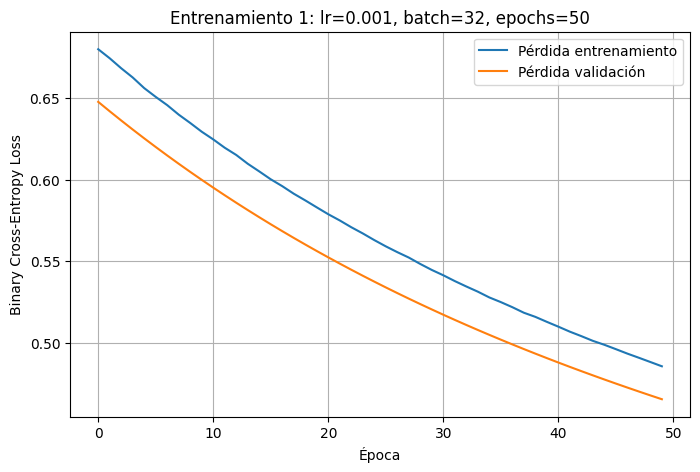


Entrenamiento 2: lr=0.001, batch_size=64, epochs=100


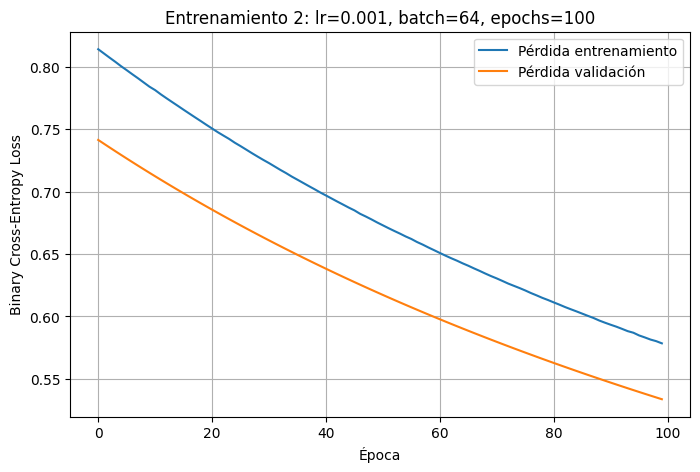


Entrenamiento 3: lr=0.01, batch_size=32, epochs=50


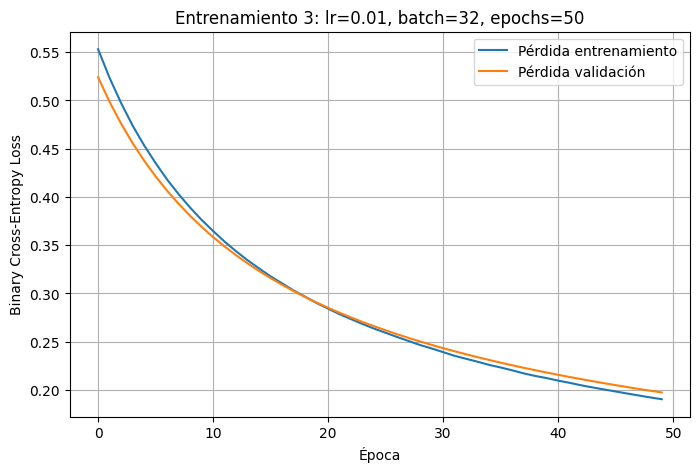


Entrenamiento 4: lr=0.01, batch_size=64, epochs=100


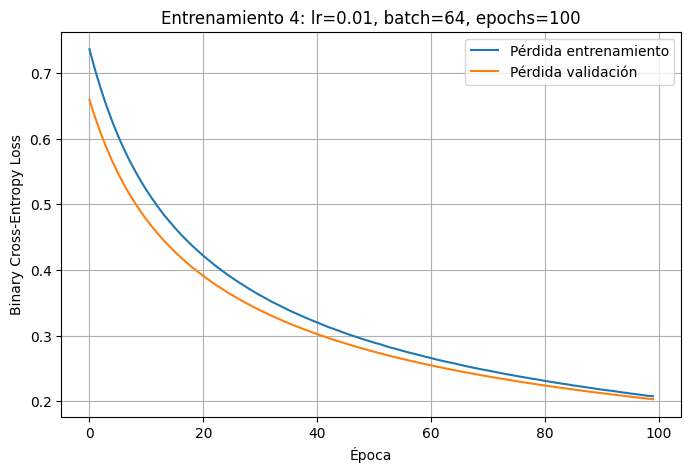


Entrenamiento 5: lr=0.01, batch_size=128, epochs=200


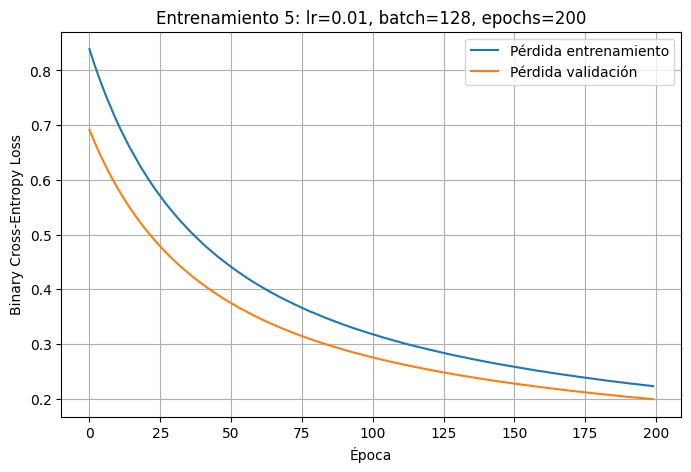


Entrenamiento 6: lr=0.1, batch_size=32, epochs=50


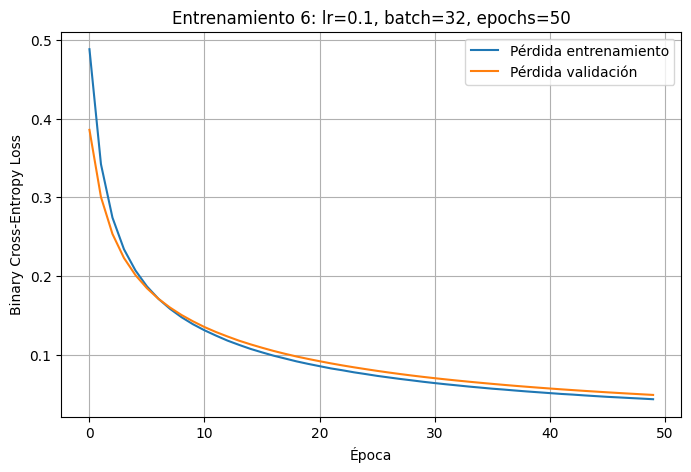


Entrenamiento 7: lr=0.1, batch_size=64, epochs=100


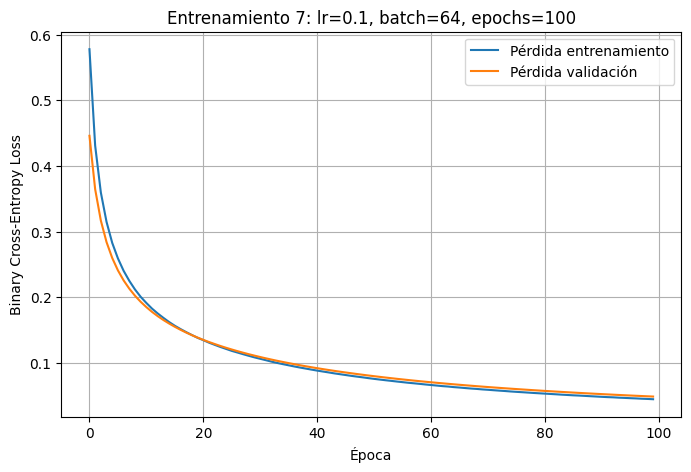


Entrenamiento 8: lr=0.1, batch_size=128, epochs=200


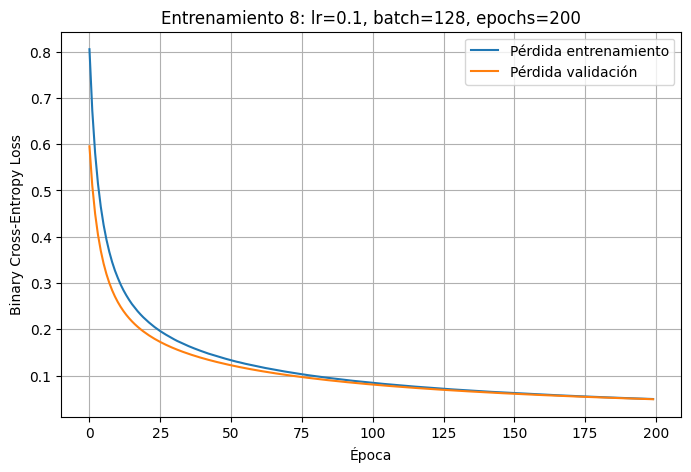


Entrenamiento 9: lr=0.001, batch_size=128, epochs=50


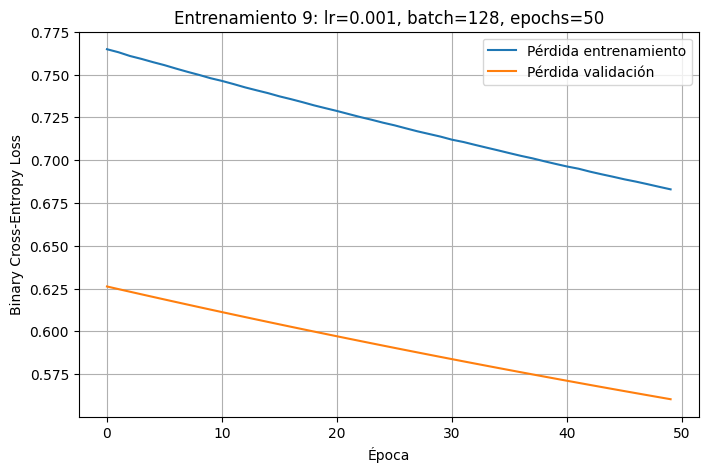


Entrenamiento 10: lr=0.01, batch_size=32, epochs=200


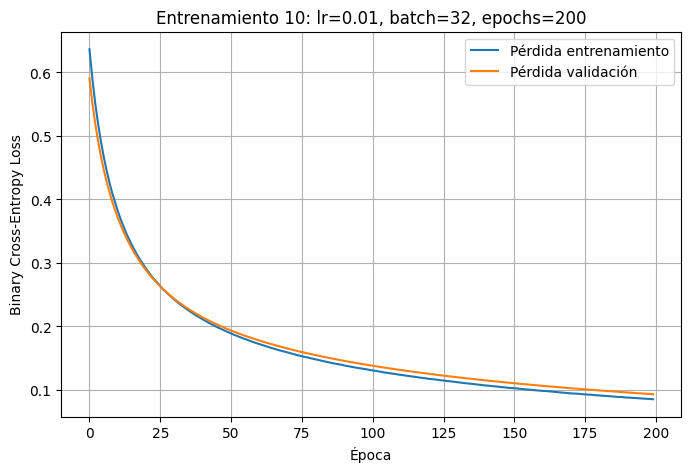

In [502]:
# Entrenamiento y evaluación 
import matplotlib.pyplot as plt

resultados = []
input_dim = X_train_std.shape[1]  # número de columnas de X de entrada

for i, config in enumerate(configs, 1):
    print(f"\nEntrenamiento {i}: lr={config['lr']}, batch_size={config['batch_size']}, epochs={config['epochs']}")
    
    # Inicializar modelo 
    modelo = RegresionLogistica(input_dim)
    
    # Entrenar modelo
    perdidas_train, perdidas_val = entrenar_modelo(
        modelo, X_train_tensor, y_train_tensor, 
        X_val_tensor, y_val_tensor,
        config["epochs"], config["batch_size"], config["lr"]
    )
    
    resultados.append({
        "config": config,
        "perdidas_train": perdidas_train,
        "perdidas_val": perdidas_val
    })
    
    # Graficar pérdidas de entrenamiento y validación
    plt.figure(figsize=(8, 5))
    plt.plot(perdidas_train, label="Pérdida entrenamiento")
    plt.plot(perdidas_val, label="Pérdida validación")
    plt.title(f"Entrenamiento {i}: lr={config['lr']}, batch={config['batch_size']}, epochs={config['epochs']}")
    plt.xlabel("Época")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

**Como se puede observar en las gráficas de los entrenamientos ejecutados con diferentes hiperparametros, la última gráfica con la combinación de learning rate de 0.01, batch de 32 y epocas de 200, tiene una función de perdida con respecto a las epocas óptima en la comparación de training contra validation, sin embargo debemos analizar las metricas para confirmar cual es el mejor entrenamiento segun precision, recall, f1 Score, y ademas teniendo en cuetna AUC y ROC.**

- **Se deben calcular las metricas por lo tanto se debe desarrollar la funcion para calcular cada una al hacer todas las iteraciones de cada uno de los 10 entrenamientos**

In [503]:
import numpy as np
import pandas as pd

# Funciones para métricas 
def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    # Convertir probabilidades en clases (0 o 1)
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calcular TP, TN, FP, FN
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    # Métricas
    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    # AUC (usando método trapezoidal con curvas ROC)
    thresholds = np.linspace(0, 1, 100)
    tpr = []
    fpr = []
    for t in thresholds:
        y_pred_t = (y_pred_proba >= t).astype(int)
        TP_t = np.sum((y_true == 1) & (y_pred_t == 1))
        TN_t = np.sum((y_true == 0) & (y_pred_t == 0))
        FP_t = np.sum((y_true == 0) & (y_pred_t == 1))
        FN_t = np.sum((y_true == 1) & (y_pred_t == 0))
        tpr.append(TP_t / (TP_t + FN_t) if (TP_t + FN_t) > 0 else 0)  # Sensibilidad
        fpr.append(FP_t / (FP_t + TN_t) if (FP_t + TN_t) > 0 else 0)  # 1 - Especificidad
    # Ordenar fpr y tpr para AUC
    fpr, tpr = zip(*sorted(zip(fpr, tpr)))
    auc = np.trapezoid(tpr, fpr)  # integración trapezoidal
    
    return accuracy, precision, recall, f1, auc


### Evaluacion de metricas y cuadro comparativo
Estas nos permitiran conocer si los entrenamientos son buenos en cuanto a falsos negativos obtenidos en el caso de recall o falsos positivos en el caso de precision , ademas de saber si en general el modelo se podria mejorar todavia mas y que tan bueno terminó siendo.

In [504]:
comparacion = []

for i, result in enumerate(resultados, 1):
    # Crear modelo con la config de este entrenamiento
    model = RegresionLogistica(input_dim)
    
    # Reentrenar el modelo con la misma config
    perdidas_train, perdidas_val = entrenar_modelo(
        model, X_train_tensor, y_train_tensor, 
        X_val_tensor, y_val_tensor,
        result["config"]["epochs"], 
        result["config"]["batch_size"], 
        result["config"]["lr"]
    )
    
    # Predicciones sobre validación
    with torch.no_grad():
        y_val_pred_proba = model(X_val_tensor).numpy().flatten()
        y_val_true = y_val_tensor.numpy().flatten()
    
    # Calcular métricas
    acc, prec, rec, f1, auc = calcular_metricas(y_val_true, y_val_pred_proba)
    
    # Guardar resultados
    comparacion.append({
        "Entrenamiento": i,
        "LR": result["config"]["lr"],
        "Batch": result["config"]["batch_size"],
        "Epochs": result["config"]["epochs"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": auc
    })

# Crear tabla comparativa
df_comparacion = pd.DataFrame(comparacion)
display(df_comparacion)


,Entrenamiento,LR,Batch,Epochs,Accuracy,Precision,Recall,F1-Score,AUC
0,1,0.001,32,50,0.860606,0.487179,0.863636,0.622951,0.941195
1,2,0.001,64,100,0.745455,0.333333,0.909091,0.487805,0.904641
2,3,0.010,32,50,0.987879,1.000000,0.909091,0.952381,0.999841
3,4,0.010,64,100,0.969697,1.000000,0.772727,0.871795,0.999364
4,5,0.010,128,200,0.975758,1.000000,0.818182,0.900000,0.999523
5,6,0.100,32,50,1.000000,1.000000,1.000000,1.000000,1.000000
6,7,0.100,64,100,1.000000,1.000000,1.000000,1.000000,1.000000
7,8,0.100,128,200,1.000000,1.000000,1.000000,1.000000,1.000000
8,9,0.001,128,50,0.757576,0.312500,0.681818,0.428571,0.833916
9,10,0.010,32,200,1.000000,1.000000,1.000000,1.000000,1.000000


Como se puede observar hubieron varios entrenamientos en los que las confuiguraciones de hiperparametros fueron optimos, de modo que en cada una de las metricas dio como resultado 1, sin embargo al utilizar un modelo con estos hiperaparametros especificamente para el testing podria no ser optimo ya que existe un gran sobreajuste, y esto hace que se pierda la capacidad de generalizacion, entonces podriamos utilizar la combinacion obtenida en el entrenamiento 3. 

### Comparación con el conjunto test para el modelo más óptimo

- **Entrenamiento del modelo óptimo**

Elegimos los hiperparámetros que dieron mejor resultado y entrenamos el modelo usando el conjunto de entrenamiento. (Entrenamiento 3 con lr de 0.01 batch de 32  y con 50 epocas)


In [505]:
# Configuración óptima (modelo 3)
config_optima = {"lr": 0.01, "batch_size": 32, "epochs": 50}

# Crear el modelo con número de features de entrada
input_dim = X_train.shape[1]
model_optimo = RegresionLogistica(input_dim)

# Entrenar el modelo con train y validar en val
perdidas_train, perdidas_val = entrenar_modelo(
    model_optimo, X_train_tensor, y_train_tensor, 
    X_val_tensor, y_val_tensor,
    config_optima["epochs"], 
    config_optima["batch_size"], 
    config_optima["lr"]
)


- **Predicciones**

Generamos las predicciones (probabilidades) del modelo sobre los conjuntos de entrenamiento y test.


In [506]:
# Predicciones en entrenamiento
with torch.no_grad():
    y_train_pred_proba = model_optimo(X_train_tensor).numpy().flatten()
    y_train_true = y_train_tensor.numpy().flatten()

# Predicciones en test
with torch.no_grad():
    y_test_pred_proba = model_optimo(X_test_tensor).numpy().flatten()
    y_test_true = y_test_tensor.numpy().flatten()


- **Métricas comparativas**

Calculamos y comparamos las métricas de entrenamiento y test para evaluar el desempeño del modelo.


In [507]:
# Métricas en train
acc_train, prec_train, rec_train, f1_train, auc_train = calcular_metricas(y_train_true, y_train_pred_proba)

# Métricas en test
acc_test, prec_test, rec_test, f1_test, auc_test = calcular_metricas(y_test_true, y_test_pred_proba)

# Comparar en tabla
comparacion_dict = {
    "Conjunto": ["Entrenamiento", "Test"],
    "Accuracy": [acc_train, acc_test],
    "Precision": [prec_train, prec_test],
    "Recall": [rec_train, rec_test],
    "F1-Score": [f1_train, f1_test],
    "AUC": [auc_train, auc_test]
}
df_comparacion_train_test = pd.DataFrame(comparacion_dict)
display(df_comparacion_train_test)


,Conjunto,Accuracy,Precision,Recall,F1-Score,AUC
0,Entrenamiento,0.986928,1.0,0.898990,0.946809,0.999788
1,Test,0.987805,1.0,0.904762,0.950000,1.000000


Como se puede observar los resultados para test son optimos debido a que se eligió la mejor configuración de hiperparametros, además se hizo un buen tratamiento de outliers y normalización de los features seleccionados, además los features seleccionados fueron óptimos para el entrenamiento.

---

- **Matriz de confusión**

Calculamos y graficamos la matriz de confusión para evaluar visualmente los resultados del modelo en el conjunto de test.


Matriz de Confusión (Test):
[[TN, FP]
 [FN, TP]]
[[143   0]
 [  2  19]]


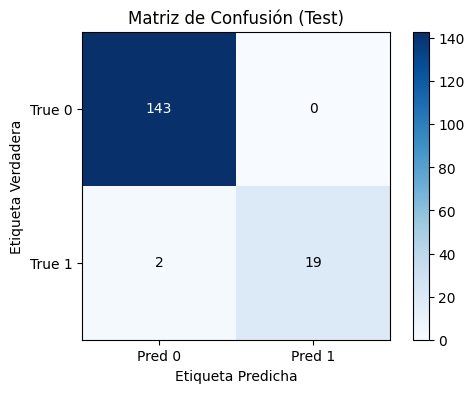

In [508]:
# Función para matriz de confusión
def matriz_confusion(y_true, y_pred_proba, umbral=0.5):
    y_pred_binary = (y_pred_proba >= umbral).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_binary == 1))
    tn = np.sum((y_true == 0) & (y_pred_binary == 0))
    fp = np.sum((y_true == 0) & (y_pred_binary == 1))
    fn = np.sum((y_true == 1) & (y_pred_binary == 0))
    return np.array([[tn, fp], [fn, tp]])

# Calcular matriz en test
conf_matrix = matriz_confusion(y_test_true, y_test_pred_proba)
print("Matriz de Confusión (Test):")
print("[[TN, FP]")
print(" [FN, TP]]")
print(conf_matrix)

# Graficar matriz
def graficar_matriz_confusion(cm):
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=["Pred 0", "Pred 1"], 
           yticklabels=["True 0", "True 1"],
           title="Matriz de Confusión (Test)",
           ylabel="Etiqueta Verdadera",
           xlabel="Etiqueta Predicha")
    # Números dentro de la matriz
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.show()

graficar_matriz_confusion(conf_matrix)


Aunque se observaron 2 falsos negativos, osea la prediccion dice que el vino no es bueno, cuando en realidad si tenia una calificacion mayor a 7 segun los features, sin embargo solo hubieron 2 casos de este tipo, por lo tanto el modelo logró clasificar correctamente la gran mayoría de los ejemplos de ambas clases. Esto indica que el entrenamiento fue efectivo y que el modelo generaliza bien al conjunto de test, manteniendo un buen desempeño general comparado con los resultados obtenidos en el conjunto de entrenamiento.
